# Análise de Desempenho — Simulador de Livro de Ofertas

Este notebook apresenta a análise do simulador de livro de ofertas desenvolvido na disciplina de Estrutura de Dados em Python.

O sistema utiliza estruturas lineares implementadas manualmente por meio de nós encadeados, conforme solicitado no enunciado do trabalho.

A proposta envolve o uso de fila, pilha, lista encadeada ordenada e motor de casamento de ordens.

In [16]:
import sys
import os
import time
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))

from ordem import OrdemNode
from fila import Fila
from pilha import Pilha
from lista_encadeada import ListaDuplamenteEncadeada
from motor_match import MotorMatch

## Estruturas Utilizadas

O simulador de livro de ofertas foi desenvolvido com estruturas de dados lineares implementadas manualmente por meio de nós encadeados.

As principais estruturas utilizadas no sistema são:

- **Ordem:** representa uma oferta de compra ou venda, contendo ID, tipo, preço, quantidade e timestamp.
- **Fila de Entrada:** armazena as ordens na sequência em que chegam ao sistema, seguindo o princípio FIFO.
- **Livro de Ofertas:** utiliza listas encadeadas ordenadas para organizar ordens de compra e venda por prioridade de preço.
- **Pilha:** registra os IDs das ordens inseridas com sucesso, permitindo a operação de desfazer.
- **Motor de Match:** realiza o casamento entre ordens de compra e venda quando os preços são compatíveis.

## Representação das Ordens

Cada ordem representa uma intenção de compra ou venda de um ativo financeiro.

A classe `OrdemNode` armazena as informações necessárias para o processamento das negociações:

- ID único;
- tipo da ordem (Compra ou Venda);
- preço;
- quantidade;
- timestamp.

In [2]:
ordem1 = OrdemNode("C", 10.50, 100)
ordem2 = OrdemNode("V", 11.00, 50)

print("Ordem 1")
print("ID:", ordem1.id)
print("Tipo:", ordem1.tipo)
print("Preço:", ordem1.preco)
print("Quantidade:", ordem1.quantidade)
print("Timestamp:", ordem1.timestamp)

print("\nOrdem 2")
print("ID:", ordem2.id)
print("Tipo:", ordem2.tipo)
print("Preço:", ordem2.preco)
print("Quantidade:", ordem2.quantidade)
print("Timestamp:", ordem2.timestamp)

Ordem 1
ID: 1
Tipo: C
Preço: 10.5
Quantidade: 100
Timestamp: 2026-06-23 22:37:26.706477

Ordem 2
ID: 2
Tipo: V
Preço: 11.0
Quantidade: 50
Timestamp: 2026-06-23 22:37:26.708645


### Análise dos Resultados

Observa-se que cada ordem recebe automaticamente um identificador único (ID) e um timestamp no momento da criação.

Essas informações permitem o controle individual das ordens e o registro da sequência temporal de entrada no sistema.

A criação de uma ordem possui complexidade O(1), pois apenas realiza atribuições de valores aos atributos do objeto.

## Fila de Entrada

A fila de entrada é responsável por armazenar as ordens antes do processamento pelo motor de negociação.

Essa estrutura segue o princípio FIFO (*First In, First Out*), ou seja, a primeira ordem inserida é a primeira ordem removida.

No contexto do simulador, isso garante que as ordens sejam processadas na mesma sequência em que chegaram ao sistema.

In [4]:
fila = Fila()

print("Fila vazia no início?", fila.is_empty())

fila.enqueue(ordem1)
fila.enqueue(ordem2)

print("Fila vazia após inserir ordens?", fila.is_empty())

primeira_ordem = fila.dequeue()
segunda_ordem = fila.dequeue()

print("\nPrimeira ordem removida da fila")
print("ID:", primeira_ordem.id)
print("Tipo:", primeira_ordem.tipo)

print("\nSegunda ordem removida da fila")
print("ID:", segunda_ordem.id)
print("Tipo:", segunda_ordem.tipo)

print("\nFila vazia no final?", fila.is_empty())

Fila vazia no início? True
Fila vazia após inserir ordens? False

Primeira ordem removida da fila
ID: 1
Tipo: C

Segunda ordem removida da fila
ID: 2
Tipo: V

Fila vazia no final? True


### Análise dos Resultados

A fila iniciou vazia, recebeu duas ordens e depois removeu essas ordens na mesma sequência em que foram inseridas.

A ordem de ID 1 foi removida antes da ordem de ID 2, demonstrando o comportamento FIFO da estrutura.

As operações de inserção (`enqueue`) e remoção (`dequeue`) possuem complexidade O(1), pois a fila mantém ponteiros para o início e para o fim da estrutura, evitando a necessidade de percorrer todos os nós.

## Sistema de Undo com Pilha

A pilha é utilizada para registrar os IDs das ordens inseridas com sucesso no livro de ofertas.

Essa estrutura segue o princípio LIFO (*Last In, First Out*), ou seja, o último elemento inserido é o primeiro a ser removido.

No contexto do simulador, isso permite identificar rapidamente a última ordem inserida, possibilitando a operação de desfazer.

In [5]:
pilha = Pilha()

print("Pilha vazia no início?", pilha.is_empty())

pilha.push(ordem1.id)
pilha.push(ordem2.id)

print("Pilha vazia após inserir IDs?", pilha.is_empty())

ultimo_id = pilha.pop()
proximo_id = pilha.pop()

print("\nÚltimo ID removido da pilha:", ultimo_id)
print("Próximo ID removido da pilha:", proximo_id)

print("\nPilha vazia no final?", pilha.is_empty())

Pilha vazia no início? True
Pilha vazia após inserir IDs? False

Último ID removido da pilha: 2
Próximo ID removido da pilha: 1

Pilha vazia no final? True


### Análise dos Resultados

A pilha iniciou vazia, recebeu os IDs das duas ordens criadas e removeu esses IDs na ordem inversa de inserção.

O ID 2 foi removido antes do ID 1, demonstrando o comportamento LIFO da estrutura.

As operações `push` e `pop` possuem complexidade O(1), pois a pilha realiza inserções e remoções diretamente no topo, sem necessidade de percorrer todos os nós.

## Livro de Ofertas

O livro de ofertas é responsável por armazenar as ordens de compra e venda que aguardam negociação.

Para atender aos requisitos do simulador, foi utilizada uma lista duplamente encadeada ordenada.

Essa estrutura permite manter as ordens organizadas por preço, facilitando a identificação das melhores ofertas disponíveis para compra e venda.

No sistema, são utilizadas duas listas:

- Lista de Compras: mantida em ordem decrescente de preço.
- Lista de Vendas: mantida em ordem crescente de preço.

### Organização das Ordens

#### Lista de Compras

```text
25 → 20 → 18 → 15
```

A melhor oferta de compra fica no início da lista.

#### Lista de Vendas

```text
10 → 12 → 14 → 18
```

A melhor oferta de venda também fica no início da lista.

In [7]:
compras = ListaDuplamenteEncadeada(ordem_crescente=False)

compra1 = OrdemNode("C", 20.0, 100)
compra2 = OrdemNode("C", 15.0, 50)
compra3 = OrdemNode("C", 25.0, 80)

compras.inserir_ordenado(compra1)
compras.inserir_ordenado(compra2)
compras.inserir_ordenado(compra3)

print("Livro de Compras:")
compras.exibir()

Livro de Compras:
ID: 5 | Preço: 25.0 | Quantidade: 80
ID: 3 | Preço: 20.0 | Quantidade: 100
ID: 4 | Preço: 15.0 | Quantidade: 50


In [8]:
vendas = ListaDuplamenteEncadeada(ordem_crescente=True)

venda1 = OrdemNode("V", 18.0, 100)
venda2 = OrdemNode("V", 10.0, 50)
venda3 = OrdemNode("V", 14.0, 80)

vendas.inserir_ordenado(venda1)
vendas.inserir_ordenado(venda2)
vendas.inserir_ordenado(venda3)

print("Livro de Vendas:")
vendas.exibir()

Livro de Vendas:
ID: 7 | Preço: 10.0 | Quantidade: 50
ID: 8 | Preço: 14.0 | Quantidade: 80
ID: 6 | Preço: 18.0 | Quantidade: 100


### Análise dos Resultados

Observa-se que as ordens são inseridas automaticamente na posição correta da lista, mantendo a ordenação por preço.

Na lista de compras, as maiores ofertas permanecem no início da estrutura. Já na lista de vendas, as menores ofertas ocupam as primeiras posições.

Esse comportamento é fundamental para o funcionamento do livro de ofertas, pois permite identificar rapidamente as melhores oportunidades de negociação.

A operação de inserção ordenada possui complexidade O(n), pois pode ser necessário percorrer todos os nós da lista até encontrar a posição correta para a nova ordem.

### Importância da Ordenação

A manutenção automática da ordenação permite que as melhores ofertas fiquem sempre posicionadas no início das listas.

Dessa forma, o sistema pode acessar rapidamente a melhor ordem de compra e a melhor ordem de venda por meio da cabeça da lista, sem necessidade de percorrer toda a estrutura.

Essa característica é fundamental para o funcionamento eficiente do motor de casamento de ordens.

## Motor de Match

O motor de match é responsável por verificar se existe compatibilidade entre as melhores ordens de compra e venda.

Como as listas estão ordenadas, o motor compara apenas o topo da lista de compras com o topo da lista de vendas.

A regra principal é:

```text
Se preço da compra >= preço da venda,
então ocorre uma transação.

In [11]:
livro_compras = ListaDuplamenteEncadeada(ordem_crescente=False)
livro_vendas = ListaDuplamenteEncadeada(ordem_crescente=True)

ordem_compra = OrdemNode("C", 20.0, 100)
ordem_venda = OrdemNode("V", 15.0, 50)

livro_compras.inserir_ordenado(ordem_compra)
livro_vendas.inserir_ordenado(ordem_venda)

motor = MotorMatch()

transacoes = motor.executar(livro_compras, livro_vendas)

print("Transações realizadas:")
for transacao in transacoes:
    print(transacao)

print("\nLivro de Compras após o match:")
livro_compras.exibir()

print("\nLivro de Vendas após o match:")
if livro_vendas.is_empty():
    print("Livro vazio")
else:
    livro_vendas.exibir()

Transações realizadas:
Compra #11 x Venda #12 | 50 ações a R$20.00

Livro de Compras após o match:
ID: 11 | Preço: 20.0 | Quantidade: 50

Livro de Vendas após o match:
Livro vazio


### Análise dos Resultados

Neste exemplo, a ordem de compra possui preço maior que a ordem de venda. Portanto, a condição para o casamento foi satisfeita.

Como a compra aceitava pagar R$ 20,00 e a venda aceitava receber R$ 15,00, o motor executou uma transação entre as duas ordens.

A quantidade negociada foi definida pelo menor volume disponível entre compra e venda. Como a venda possuía quantidade 50 e a compra possuía quantidade 100, foram negociadas 50 ações.

O preço de execução foi R$ 20,00, pois o motor utiliza o preço da ordem que chegou primeiro ao sistema. Neste caso, a ordem de compra foi criada antes da ordem de venda.

Após a transação, a ordem de venda foi totalmente atendida e removida do livro. A ordem de compra permaneceu com quantidade restante de 50 ações. Por isso, o livro de vendas aparece como vazio após o match.

## Integração do Sistema

Após a implementação das estruturas individuais, foi realizada a integração de todos os componentes do simulador.

O fluxo de processamento ocorre da seguinte forma:

```text
Nova Ordem
     │
     ▼
Fila de Entrada
     │
     ▼
Livro de Ofertas
(Compras e Vendas)
     │
     ▼
Pilha de Undo
     │
     ▼
Motor de Match
     │
     ▼
Histórico de Transações
```

Quando uma nova ordem é criada, ela é inicialmente inserida na fila de entrada. Em seguida, a ordem é transferida para o livro de ofertas correspondente (compra ou venda), sendo registrada na pilha de undo.

Após cada inserção, o motor de match verifica se existe compatibilidade entre as melhores ofertas de compra e venda. Caso exista, uma transação é executada e registrada no histórico do sistema.

In [12]:
# Estruturas do sistema

fila = Fila()
pilha = Pilha()

compras = ListaDuplamenteEncadeada(ordem_crescente=False)
vendas = ListaDuplamenteEncadeada(ordem_crescente=True)

motor = MotorMatch()

# Criação das ordens

ordem_a = OrdemNode("C", 20.0, 100)
ordem_b = OrdemNode("V", 15.0, 50)

# Entrada na fila

fila.enqueue(ordem_a)
fila.enqueue(ordem_b)

print("Ordens inseridas na fila.")

# Processamento da fila

while not fila.is_empty():

    ordem = fila.dequeue()

    if ordem.tipo == "C":
        compras.inserir_ordenado(ordem)
    else:
        vendas.inserir_ordenado(ordem)

    pilha.push(ordem.id)

# Execução do motor de match

transacoes = motor.executar(compras, vendas)

print("\nTransações realizadas:")

for t in transacoes:
    print(t)

print("\nLivro de Compras:")

if compras.is_empty():
    print("Livro vazio")
else:
    compras.exibir()

print("\nLivro de Vendas:")

if vendas.is_empty():
    print("Livro vazio")
else:
    vendas.exibir()

Ordens inseridas na fila.

Transações realizadas:
Compra #13 x Venda #14 | 50 ações a R$20.00

Livro de Compras:
ID: 13 | Preço: 20.0 | Quantidade: 50

Livro de Vendas:
Livro vazio


### Análise dos Resultados

O teste integrado demonstrou o funcionamento conjunto de todas as estruturas desenvolvidas no projeto.

Inicialmente, as ordens foram inseridas na fila de entrada. Durante o processamento, cada ordem foi encaminhada para o respectivo livro de ofertas e registrada na pilha de undo.

Após a inserção das ordens, o motor de match identificou compatibilidade entre a melhor oferta de compra e a melhor oferta de venda, executando uma transação automaticamente.

Observou-se que a ordem de venda foi completamente atendida e removida do livro, enquanto a ordem de compra permaneceu com quantidade remanescente.

Esse resultado confirma a correta integração entre fila, pilha, lista encadeada e motor de match.

## Análise Teórica

A eficiência do simulador depende diretamente das estruturas de dados utilizadas. A seguir são apresentadas as principais operações implementadas e suas respectivas complexidades assintóticas.

| Estrutura | Operação | Complexidade |
|------------|------------|------------|
| Ordem | Criação de ordem | O(1) |
| Fila | Enqueue | O(1) |
| Fila | Dequeue | O(1) |
| Pilha | Push | O(1) |
| Pilha | Pop | O(1) |
| Lista Encadeada | Inserção ordenada | O(n) |
| Lista Encadeada | Remoção por ID | O(n) |
| Lista Encadeada | Topo | O(1) |
| Lista Encadeada | Verificar vazia | O(1) |
| Motor de Match | Consulta das melhores ofertas | O(1) |

### Discussão das Complexidades

As estruturas fila e pilha apresentam operações de inserção e remoção com complexidade O(1), pois utilizam ponteiros para acessar diretamente os elementos relevantes.

A lista duplamente encadeada exige busca sequencial para encontrar a posição correta de inserção ou um elemento específico para remoção. Por esse motivo, as operações de inserção ordenada e remoção possuem complexidade O(n).

O motor de match aproveita a ordenação das listas para acessar diretamente as melhores ofertas por meio da cabeça da lista, realizando essa consulta em tempo constante O(1).

Dessa forma, o principal custo computacional do sistema está associado à manutenção das listas ordenadas de compra e venda.

## Metodologia Experimental

Para avaliar o comportamento das estruturas implementadas, foram realizados testes práticos utilizando diferentes cenários de execução.

Os experimentos tiveram como objetivo verificar o funcionamento correto das estruturas de dados e observar o impacto do crescimento do volume de ordens no desempenho do sistema.

Os testes foram conduzidos utilizando o ambiente Python e o Jupyter Notebook, permitindo a execução controlada dos experimentos e a análise dos resultados obtidos.

### Cenários Avaliados

Os experimentos foram divididos em diferentes etapas:

- Criação e manipulação de ordens de compra e venda;
- Inserção e remoção de elementos na fila de entrada;
- Operações de empilhamento e desempilhamento na pilha de undo;
- Inserção ordenada de ordens no livro de ofertas;
- Execução do motor de match;
- Testes integrados envolvendo todas as estruturas simultaneamente.

### Métricas Observadas

Durante os experimentos foram observados os seguintes aspectos:

- Correção do comportamento das estruturas implementadas;
- Manutenção da ordenação das listas de compra e venda;
- Funcionamento do mecanismo de undo;
- Execução correta do casamento de ordens;
- Tempo de processamento para diferentes quantidades de elementos.

Essas observações serão utilizadas na seção de resultados para comparar o comportamento esperado teoricamente com os resultados obtidos experimentalmente.

## Resultados Experimentais

Nesta seção são apresentados experimentos realizados com as principais estruturas de dados implementadas no simulador.

Os testes tiveram como objetivo comparar o comportamento das estruturas diante de diferentes quantidades de ordens, observando o tempo necessário para executar suas operações principais.

In [17]:
def medir_tempo_medio(funcao_teste, n, repeticoes=10):

    tempos = []

    for _ in range(repeticoes):
        tempos.append(funcao_teste(n))

    return sum(tempos) / len(tempos)

In [29]:
tamanhos = [100, 500, 1000, 5000, 10000]
REPETICOES_INTERNAS = 100

### Experimento 1 – Desempenho da Fila

Neste experimento foi avaliado o tempo necessário para inserir e remover ordens da fila de entrada.

Como a fila foi implementada utilizando lista encadeada com ponteiros para frente e para trás, espera-se que as operações de inserção (enqueue) e remoção (dequeue) apresentem comportamento eficiente.

In [30]:
def testar_fila(n):
    inicio = time.perf_counter()

    for _ in range(REPETICOES_INTERNAS):
        fila = Fila()

        for i in range(n):
            fila.enqueue(OrdemNode("C", 10.0, 100))

        while not fila.is_empty():
            fila.dequeue()

    fim = time.perf_counter()

    return (fim - inicio) / REPETICOES_INTERNAS

In [31]:
tempos_fila = []

for n in tamanhos:

    tempo = medir_tempo_medio(testar_fila, n)

    tempos_fila.append(tempo)

    print(f"{n} ordens -> {tempo:.6f} s")

100 ordens -> 0.000708 s
500 ordens -> 0.002117 s
1000 ordens -> 0.004119 s
5000 ordens -> 0.032715 s
10000 ordens -> 0.063898 s


### Experimento 2 – Desempenho da Pilha

O segundo experimento avaliou o desempenho da pilha utilizada para implementar o mecanismo de undo.

Foram realizadas operações sucessivas de empilhamento (push) e desempilhamento (pop).

In [32]:
def testar_pilha(n):
    inicio = time.perf_counter()

    for _ in range(REPETICOES_INTERNAS):
        pilha = Pilha()

        for i in range(n):
            pilha.push(i)

        while not pilha.is_empty():
            pilha.pop()

    fim = time.perf_counter()

    return (fim - inicio) / REPETICOES_INTERNAS

In [33]:
tempos_pilha = []

for n in tamanhos:

    tempo = medir_tempo_medio(testar_pilha, n)

    tempos_pilha.append(tempo)

    print(f"{n} IDs -> {tempo:.6f} s")

100 IDs -> 0.000120 s
500 IDs -> 0.000525 s
1000 IDs -> 0.000993 s
5000 IDs -> 0.007422 s
10000 IDs -> 0.014583 s


### Experimento 3 – Desempenho da Lista Encadeada

Neste experimento foi analisado o custo da inserção ordenada das ordens de compra.

Diferentemente da fila e da pilha, a lista encadeada precisa localizar a posição correta de inserção, tornando essa operação relativamente mais custosa.

In [34]:
def testar_lista(n):
    inicio = time.perf_counter()

    for _ in range(REPETICOES_INTERNAS):
        lista = ListaDuplamenteEncadeada(ordem_crescente=False)

        for i in range(n):
            lista.inserir_ordenado(
                OrdemNode("C", float(i), 100)
            )

    fim = time.perf_counter()

    return (fim - inicio) / REPETICOES_INTERNAS

In [35]:
tempos_lista = []

for n in tamanhos:

    tempo = medir_tempo_medio(testar_lista, n)

    tempos_lista.append(tempo)

    print(f"{n} ordens -> {tempo:.6f} s")

100 ordens -> 0.000891 s
500 ordens -> 0.003338 s
1000 ordens -> 0.008207 s
5000 ordens -> 0.044232 s
10000 ordens -> 0.082259 s


In [36]:
print("=" * 72)
print(f"{'Quantidade':<12}{'Fila (s)':<15}{'Pilha (s)':<15}{'Lista (s)':<15}")
print("=" * 72)

for i in range(len(tamanhos)):
    print(
        f"{tamanhos[i]:<12}"
        f"{tempos_fila[i]:<15.6f}"
        f"{tempos_pilha[i]:<15.6f}"
        f"{tempos_lista[i]:<15.6f}"
    )

print("=" * 72)

Quantidade  Fila (s)       Pilha (s)      Lista (s)      
100         0.000708       0.000120       0.000891       
500         0.002117       0.000525       0.003338       
1000        0.004119       0.000993       0.008207       
5000        0.032715       0.007422       0.044232       
10000       0.063898       0.014583       0.082259       


Os valores apresentados na Tabela acima representam o tempo médio obtido após dez execuções de cada experimento, reduzindo o impacto de oscilações ocasionais do ambiente de execução.

### Gráfico – Comparação do Tempo Médio de Execução das Estruturas de Dados

O gráfico abaixo facilita a comparação visual do crescimento do tempo médio de execução conforme aumenta a quantidade de ordens processadas.

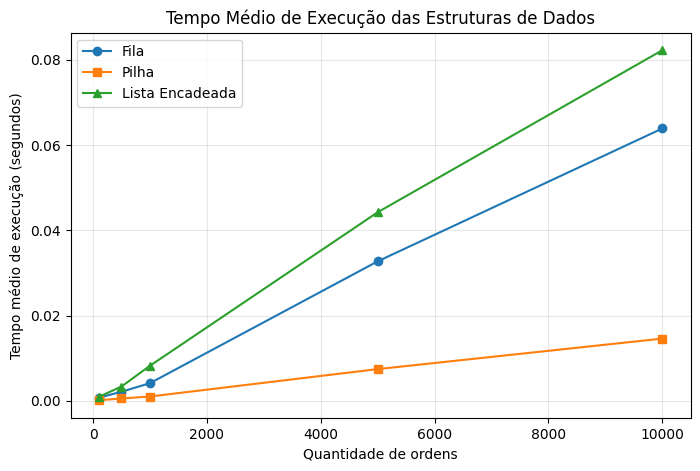

In [37]:
plt.figure(figsize=(8,5))

plt.plot(tamanhos, tempos_fila, marker="o", label="Fila")
plt.plot(tamanhos, tempos_pilha, marker="s", label="Pilha")
plt.plot(tamanhos, tempos_lista, marker="^", label="Lista Encadeada")

plt.title("Tempo Médio de Execução das Estruturas de Dados")
plt.xlabel("Quantidade de ordens")
plt.ylabel("Tempo médio de execução (segundos)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### Análise dos Resultados
Os experimentos permitiram comparar o desempenho das principais estruturas de dados utilizadas no simulador.

Observa-se que, à medida que a quantidade de ordens aumenta, o tempo médio de execução também cresce para todas as estruturas analisadas. Esse comportamento era esperado, uma vez que um maior volume de elementos exige um número maior de operações.

A pilha apresentou os menores tempos médios de execução em todos os experimentos, seguida pela fila. Isso ocorre porque ambas realizam inserções e remoções em tempo constante, apresentando elevada eficiência nessas operações.

A lista encadeada apresentou os maiores tempos médios, principalmente para maiores quantidades de ordens. Esse resultado está de acordo com a análise teórica, pois a inserção ordenada exige percorrer a lista até encontrar a posição correta para o novo elemento, aumentando o custo computacional.

A fila apresentou desempenho intermediário, mantendo tempos próximos aos da pilha devido à complexidade O(1) de suas operações principais, embora com uma pequena sobrecarga decorrente do gerenciamento simultâneo dos ponteiros de início e fim.

Durante os experimentos foram observadas pequenas variações entre algumas execuções individuais, fenômeno comum em ambientes reais devido à influência do sistema operacional e do interpretador Python. Para reduzir esse efeito, cada experimento foi executado diversas vezes e os resultados apresentados correspondem ao tempo médio obtido.

Dessa forma, os resultados experimentais confirmam o comportamento esperado das estruturas implementadas e demonstram que o simulador executa corretamente suas operações para diferentes volumes de dados.


## Conclusão

Este projeto permitiu o desenvolvimento de um simulador de livro de ofertas utilizando exclusivamente estruturas de dados lineares implementadas manualmente por meio de nós encadeados, conforme os requisitos da disciplina. Foram construídas e integradas as estruturas de fila, pilha, lista duplamente encadeada ordenada e o motor de casamento de ordens, formando um sistema capaz de representar de maneira simplificada o funcionamento de um ambiente de negociação.

Ao longo do desenvolvimento, foi possível verificar na prática o comportamento de cada estrutura e compreender a importância da escolha da estrutura de dados mais adequada para cada operação. A fila garantiu o processamento das ordens na sequência de chegada, a pilha possibilitou a implementação do mecanismo de desfazer operações e a lista encadeada manteve automaticamente as ordens organizadas por prioridade de preço, permitindo que o motor de match localizasse rapidamente as melhores ofertas disponíveis.

Os experimentos realizados confirmaram as expectativas teóricas de complexidade assintótica. As operações de inserção e remoção da fila e da pilha apresentaram desempenho compatível com complexidade O(1), enquanto a inserção ordenada na lista encadeada apresentou crescimento do tempo de execução conforme aumentou a quantidade de ordens processadas, comportamento esperado para uma operação de complexidade O(n).

Os testes também demonstraram que pequenas variações nos tempos de execução podem ocorrer devido às características do ambiente de execução e do interpretador Python. Para reduzir esse efeito, cada experimento foi executado diversas vezes, sendo considerado o tempo médio obtido, tornando os resultados mais consistentes e representativos.

Por fim, conclui-se que os objetivos propostos foram plenamente atingidos. Além de consolidar os conceitos fundamentais de estruturas de dados, o projeto proporcionou uma aplicação prática desses conhecimentos em um problema inspirado em sistemas reais do mercado financeiro, evidenciando a relação entre análise teórica, implementação e desempenho computacional.

## Considerações Finais

O notebook apresentou a implementação, validação e análise de desempenho das principais estruturas utilizadas no simulador de livro de ofertas, demonstrando a relação entre teoria e prática por meio de experimentos controlados e análise dos resultados obtidos.